In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library dan modul yang diperlukan untuk seluruh alur kerja pengolahan citra, ekstraksi fitur, klasifikasi, hingga evaluasi model. Library os digunakan untuk berinteraksi dengan sistem operasi, seperti mengakses dan mengelola struktur folder dataset. OpenCV (cv2) berfungsi untuk membaca, memanipulasi, dan memproses citra digital. NumPy (np) digunakan untuk menangani komputasi numerik dan operasi array multidimensi, sedangkan Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil analisis. Pandas (pd) digunakan untuk menyimpan dan mengorganisasi data hasil ekstraksi fitur ke dalam bentuk tabel (DataFrame). Untuk kebutuhan machine learning, library scikit-learn (sklearn) menyediakan modul train_test_split dan cross_val_predict untuk pembagian data serta validasi silang. Algoritma klasifikasi yang digunakan meliputi RandomForestClassifier, SVC (Support Vector Classifier), dan KNeighborsClassifier. Guna mengekstrak fitur tekstur dari citra, digunakan fungsi graycomatrix dan graycoprops dari skimage.feature untuk perhitungan matriks GLCM, didukung oleh scipy.stats untuk menghitung nilai entropi. Terakhir, evaluasi performa model dilakukan menggunakan berbagai metrik seperti akurasi, presisi, recall, f1-score, serta confusion_matrix yang divisualisasikan secara estetis menggunakan ConfusionMatrixDisplay dan library seaborn (sns).

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 500
Kelas: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


Pada tahap ini, dilakukan inisialisasi list kosong (data, labels, file_name) serta penentuan dimensi standar IMG_SIZE sebesar 128 x 128 piksel sebagai persiapan pemrosesan data. Menggunakan perulangan bertingkat (nested loop) dengan fungsi os.listdir dan os.path.join, program otomatis menelusuri setiap sub-folder di dalam direktori "dataset" untuk membaca file citra menggunakan OpenCV (cv.imread). Terdapat proses validasi (if img is None) untuk melewati file yang rusak, sedangkan citra yang valid akan disimpan ke dalam list bersama dengan nama sub-folder sebagai label kelas dan format penamaan baru yang terstruktur.

# Data Preparation
### Define Preprocessing Function

In [3]:
TARGET_SIZE = (128, 128)

def re_gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) #konvolusi sumbu x
    gy = convolution(img, kernely) #konvolusi sumbu y
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas) #normalisasi ke 0-255
    return np.clip(canvas, 0, 255).astype(np.uint8)  # batas nilai dan konversi

#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel sobel sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height-center):
        for j in range(center, width-center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i,j] != 255:
                    hasil[i,j] = 0
    return hasil

def erosi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant', constant_values=0)
    canvas = np.zeros_like(padded)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            if np.all(region[kernel == 1] == 255):
                canvas[i+pad_size, j+pad_size] = 255

    return canvas[pad_size:-pad_size, pad_size:-pad_size]

def opening(img, kernel):
    return dilasi(erosi(img,kernel),kernel)

def closing(img,kernel):
    return erosi(dilasi(img,kernel),kernel)

kernel_3x3 = np.array([ 
    [1,1,1], 
    [1,1,1], 
    [1,1,1] 
]) 

## Tahap Pra-pemrosesan Citra Dasar
Blok kode ini mendefinisikan fungsi-fungsi awal untuk pra-pemrosesan citra digital. Fungsi `re_gray` bertugas mengubah ukuran dimensi gambar menjadi 128x128 piksel dan mengonversinya secara otomatis ke format *grayscale*. Fungsi `median` mereduksi *noise* atau bintik pada gambar menggunakan filter penyaringan *median blur*. 

## Operasi Konvolusi dan Deteksi Tepi
Fungsi `convolution` melakukan komputasi konvolusi dua dimensi secara manual dengan menambahkan bantalan nol (*zero padding*) agar dimensi citra keluaran tetap sama dengan aslinya. Fungsi `edge` memanfaatkan konvolusi ini untuk mengekstraksi fitur tepi dengan menghitung dan menormalisasi magnitudo gradien dari sumbu X dan Y. Proses ekstraksi ini didukung oleh matriks kernel operator Sobel (3x3) untuk deteksi tepi yang lebih tahan *noise*, serta operator Roberts Cross (2x2) untuk komputasi gradien diagonal yang lebih cepat.

## Thresholding
Fungsi `thresholding` berfungsi untuk mengonversi citra *grayscale* menjadi citra biner murni. Algoritma ini bekerja dengan memindai intensitas setiap piksel lalu membandingkannya dengan nilai ambang batas (*threshold*). Piksel yang intensitasnya melampaui batas tersebut akan diubah menjadi putih (255), sedangkan yang berada di bawah atau sama dengan batas akan ditekan menjadi hitam pekat (0).

## Operasi Morfologi Citra
Blok kode terakhir ini mendefinisikan operasi morfologi citra biner yang menggunakan elemen penstruktur berupa matriks 3x3 (`kernel_3x3`) yang seluruhnya bernilai 1. Operasi dasar meliputi fungsi `dilasi` untuk menebalkan atau memperluas area piksel objek utama, serta `erosi` untuk mengikis area batas terluarnya. Selanjutnya, didefinisikan pula operasi gabungan lanjutan: fungsi `opening` (erosi diikuti dilasi) yang sangat efektif untuk membersihkan *noise* kecil di area latar belakang, dan fungsi `closing` (dilasi diikuti erosi) yang berguna untuk menambal lubang-lubang kecil di bagian dalam objek.

In [4]:
def prepro(image):
    img = re_gray(image)
    img = median(img)
    sobel = edge(img, sobelX, sobelY)
    roberts = edge(sobel, robertsX, robertsY)
    thresh = thresholding(roberts, 10)
    open = opening(thresh, kernel_3x3)
    close = closing(open, kernel_3x3)

    return close

## Alur Utama Pra-pemrosesan Citra Terintegrasi
Blok kode ini mendefinisikan fungsi `prepro` yang merangkai seluruh komponen pengolahan sebelumnya menjadi satu eksekusi alur (*pipeline*) yang utuh. Proses dimulai secara berurutan dengan standardisasi citra (`re_gray`), dan reduksi bintik *noise* (`median`). Setelah kualitas dasar citra diperbaiki, program melakukan deteksi tepi secara bertingkat menggunakan operator Sobel yang dilanjutkan dengan operator Roberts. 

Hasil ekstraksi tepi tersebut kemudian dikonversi menjadi citra biner melalui fungsi `thresholding` dengan menetapkan nilai batas intensitas sebesar 10. Sebagai langkah penyempurnaan akhir, citra biner tersebut diproses menggunakan operasi morfologi `opening` untuk membersihkan sisa *noise* di latar belakang, dan langsung diikuti dengan `closing` untuk menambal lubang-lubang kecil pada area objek. Citra hasil dari operasi *closing* inilah yang dikembalikan sebagai *output* final dari sistem pra-pemrosesan.

## Implementasi dan Visualisasi Hasil (Percobaan 4)
Blok kode ini berfungsi untuk menerapkan seluruh tahapan pra-pemrosesan ke dalam kumpulan data citra dan memvisualisasikan hasilnya. Pertama, didefinisikan sebuah fungsi *wrapper* bernama `percobaan4` yang akan memanggil alur `prepro` sebelumnya. Fungsi ini kemudian diaplikasikan secara massal pada seluruh citra mentah di dalam dataset menggunakan metode *list comprehension*, dan citra yang sudah terproses disimpan ke dalam variabel *list* baru.

Selanjutnya, program mengekstrak label-label atau kategori unik dari dataset yang ada dan mengurutkannya. Melalui perulangan *loop* untuk setiap label kategori yang unik, program mencari indeks citra mana saja yang bersesuaian dengan label tersebut. Sistem kemudian memanfaatkan *library* Matplotlib untuk membuat sebuah kanvas *figure* berupa *grid* (tata letak) berukuran 4 baris dan 6 kolom, yang dirancang untuk menampilkan maksimal 24 sampel citra secara bersamaan untuk setiap kategorinya.

Pada tahap akhir visualisasinya, citra-citra yang telah melewati tahap pra-pemrosesan (termasuk deteksi tepi dan morfologi) dipetakan satu per satu ke dalam sel *grid* tersebut menggunakan format peta warna *grayscale*. Sumbu koordinat (X dan Y) pada setiap subplot dinonaktifkan agar tampilan lebih bersih. Setelah proporsi ruang dan tata letaknya disesuaikan secara otomatis agar tidak saling tumpang tindih, keseluruhan kumpulan gambar tersebut akhirnya dirender dan ditampilkan ke layar.

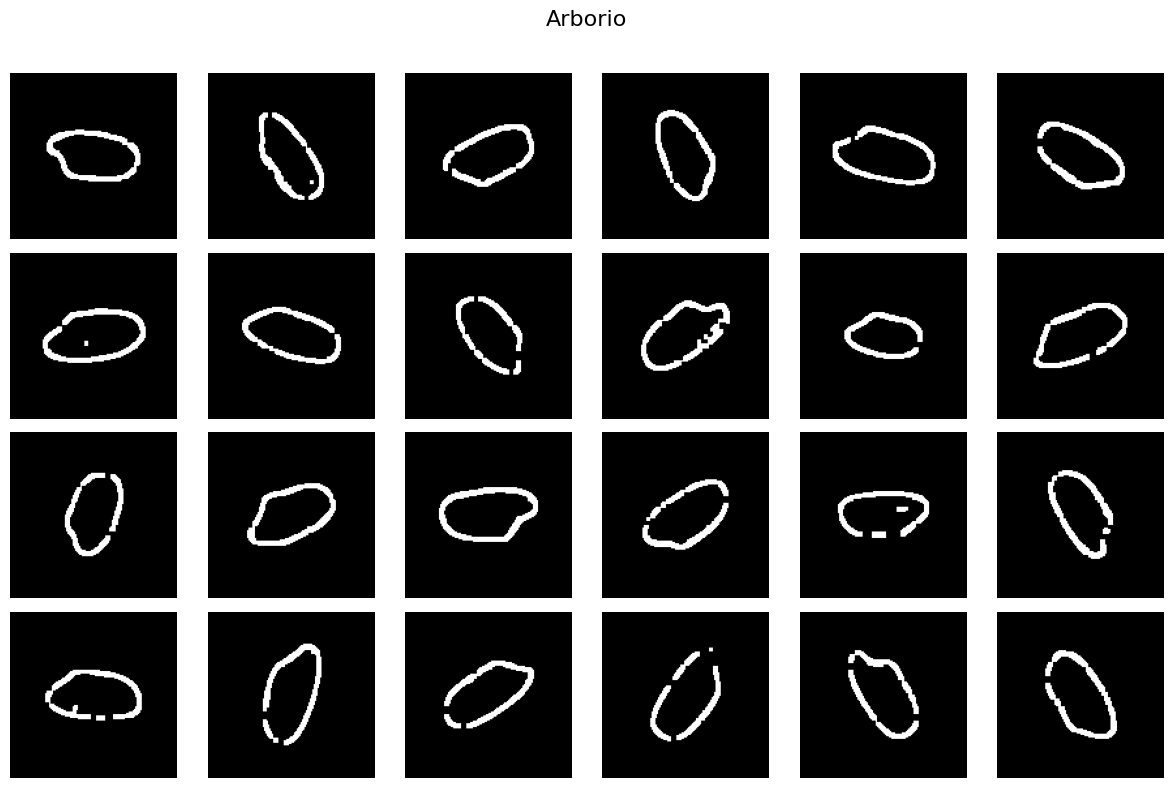

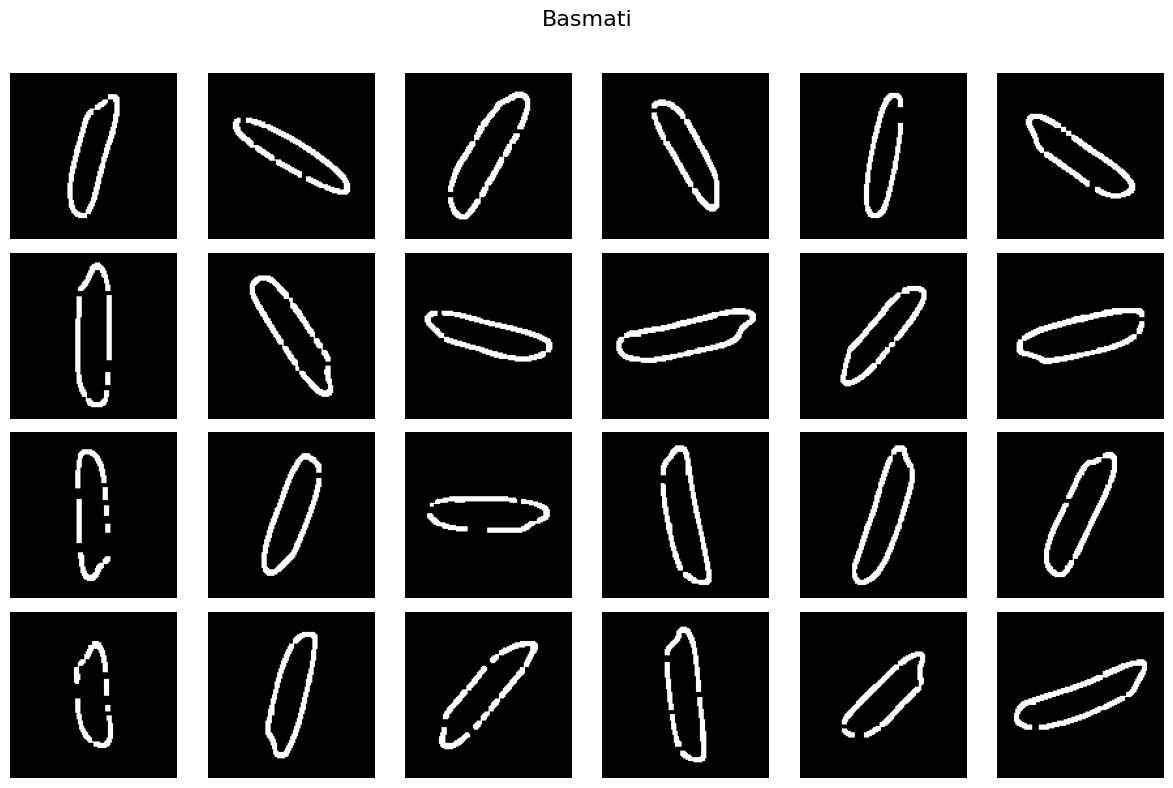

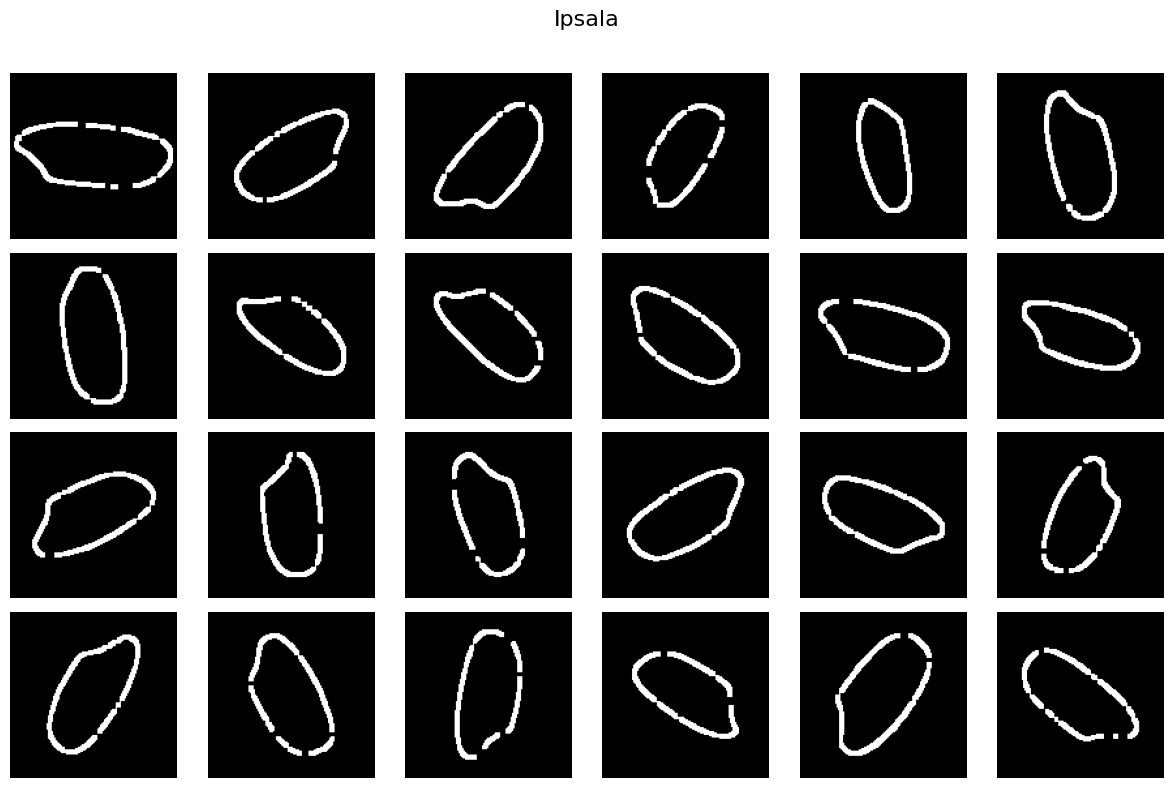

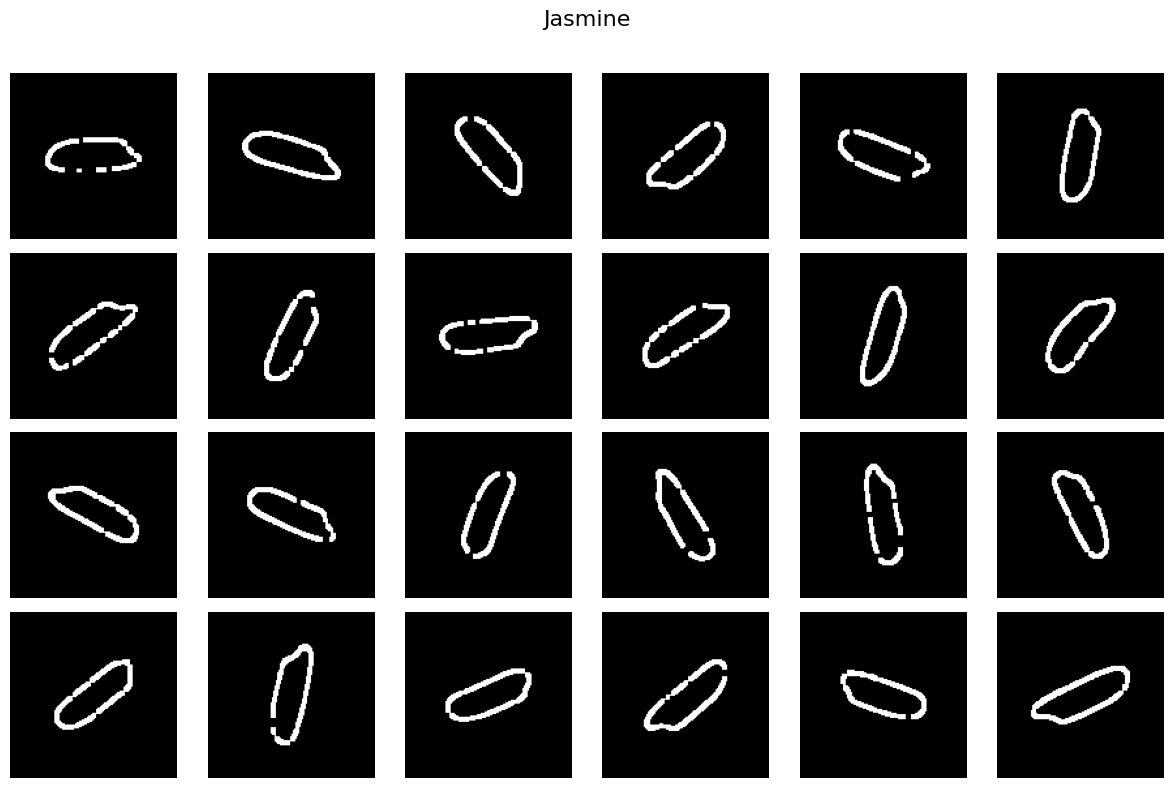

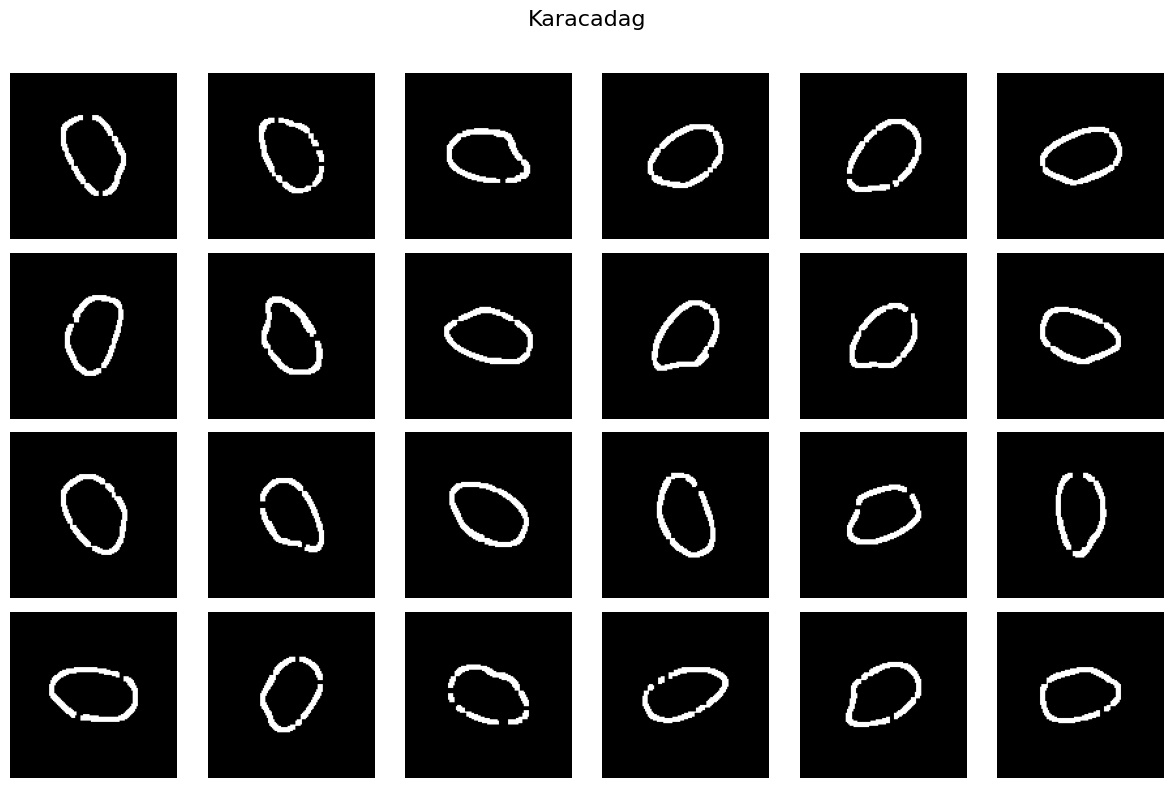

In [5]:
def percobaan4(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan4(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

## Ekstraksi Fitur Tekstur dengan GLCM
Blok kode ini mendefinisikan fungsi `glcm` untuk mengekstraksi fitur tekstur citra menggunakan metode *Gray-Level Co-occurrence Matrix* (GLCM). Fungsi menerima masukan citra dan sudut komputasi (0, 45, 90, atau 135 derajat) yang akan dikonversi menjadi satuan radian. Jika input sudut tidak sesuai, fungsi akan memicu pesan kesalahan *ValueError*. 

Setelah sudut divalidasi, fungsi membentuk matriks kookurensi melalui `graycomatrix` dengan pengaturan jarak antarpiksel sebesar 1 dan cakupan 256 tingkat keabuan. Parameter `symmetric` dan `normed` diaktifkan agar matriks yang dihasilkan bersifat simetris dan dinormalisasi menjadi nilai probabilitas, yang kemudian dikembalikan sebagai hasil akhir untuk keperluan analisis tekstur.

In [7]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi Fitur Statistik GLCM
Blok kode ini mendefinisikan serangkaian fungsi singkat untuk menghitung berbagai metrik fitur tekstur spesifik dari matriks GLCM yang telah dibentuk. Enam fitur utama—yaitu korelasi, disimilaritas, homogenitas, kontras, ASM (*Angular Second Moment*), dan energi—diekstraksi secara langsung dengan memanfaatkan fungsi bawaan `graycoprops`. 

Sementara itu, fungsi terakhir (`entropyGlcm`) dibuat khusus untuk menghitung nilai entropi. Pada proses komputasi entropi ini, dimensi matriks GLCM harus diratakan terlebih dahulu menjadi susunan satu dimensi (*flatten*) menggunakan metode `ravel()` sebelum nilainya dapat dihitung.

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [9]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi4.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Arborio_1.jpg,Arborio,576.008858,1193.341187,1080.016609,1402.982206,0.991142,0.981648,0.983391,0.978424,...,0.895092,0.889652,0.950077,0.944853,0.946093,0.943213,0.899991,0.794347,0.812483,0.758219
1,Arborio_2.jpg,Arborio,1096.016855,943.384587,728.011196,1652.938806,0.983145,0.985492,0.988804,0.974580,...,0.898348,0.883968,0.944906,0.945751,0.947812,0.940196,0.813920,0.841022,0.876399,0.721450
2,Arborio_3.jpg,Arborio,720.011073,1499.739599,1032.015871,1072.394445,0.988927,0.976936,0.984129,0.983508,...,0.893021,0.891737,0.947465,0.940970,0.944998,0.944318,0.878800,0.749420,0.826280,0.820822
3,Arborio_4.jpg,Arborio,1048.016117,1040.141980,672.010335,1467.487135,0.983883,0.984004,0.989666,0.977432,...,0.900528,0.888029,0.945991,0.945700,0.948962,0.942353,0.819404,0.822092,0.884198,0.748998
4,Arborio_5.jpg,Arborio,680.010458,1201.404303,1176.018086,1588.433877,0.989542,0.981524,0.981915,0.975572,...,0.888993,0.882224,0.946786,0.942295,0.942864,0.939268,0.887852,0.803331,0.806049,0.739974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Karacadag_96.jpg,Karacadag,704.010827,999.826400,904.013903,1362.666625,0.989173,0.984624,0.986098,0.979044,...,0.893264,0.885762,0.946712,0.944002,0.945126,0.941149,0.883616,0.835939,0.850553,0.776400
496,Karacadag_97.jpg,Karacadag,864.013287,1362.666625,688.010581,1015.952632,0.986713,0.979044,0.989419,0.984376,...,0.911514,0.906015,0.953348,0.949146,0.954733,0.951848,0.829686,0.733401,0.864380,0.801234
497,Karacadag_98.jpg,Karacadag,792.012180,1346.540393,760.011688,943.384587,0.987820,0.979292,0.988312,0.985492,...,0.887799,0.884305,0.941976,0.937189,0.942231,0.940375,0.878985,0.795773,0.883874,0.856919
498,Karacadag_99.jpg,Karacadag,768.011811,886.942774,728.011196,1241.719883,0.988189,0.986360,0.988804,0.980904,...,0.912043,0.903803,0.954695,0.953457,0.955010,0.950685,0.846383,0.823922,0.854384,0.753491


## Penerapan Ekstraksi Fitur secara Massal
Blok kode ini mengeksekusi komputasi GLCM dan ekstraksi fitur statistik untuk seluruh citra dalam dataset. Proses ini dilakukan melalui serangkaian perulangan (*loop*). Tahap pertama berfokus pada pembentukan dan penyimpanan matriks GLCM dari setiap citra ke dalam empat arah sudut komputasi (0, 45, 90, dan 135 derajat). 

Setelah matriks GLCM berhasil dibentuk, program menjalankan beberapa perulangan lanjutan untuk mengekstraksi tujuh jenis fitur tekstur (korelasi, kontras, disimilaritas, homogenitas, entropi, ASM, dan energi) dari masing-masing matriks tersebut. Seluruh hasil komputasi kemudian disimpan ke dalam variabel *list* terpisah secara spesifik berdasarkan jenis fitur dan arah sudutnya, yang nantinya akan disusun menjadi dataset numerik untuk keperluan pelatihan model.

## Seleksi Fitur Berbasis Korelasi dan Visualisasi
Blok kode ini melakukan tahap reduksi dimensi dengan menyeleksi fitur berdasarkan tingkat korelasinya. Program menghitung matriks korelasi antar seluruh fitur numerik dan membandingkannya dengan nilai ambang batas (*threshold*) sebesar 0,95. Jika terdapat pasangan fitur dengan nilai korelasi absolut mencapai atau melebihi batas tersebut, salah satu fitur akan dieliminasi untuk mencegah redundansi informasi.

Setelah penyaringan selesai, fitur-fitur yang lolos seleksi diekstrak ke dalam variabel baru (`x_new`) sebagai data masukan akhir. Program kemudian mencetak perbandingan jumlah fitur sebelum dan sesudah seleksi beserta nama-namanya. Terakhir, korelasi dari kumpulan fitur terpilih divisualisasikan ulang menggunakan grafik peta panas (*heatmap*) untuk memastikan interaksi antarfitur sudah ideal.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 12
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Entropy0', 'Entropy45', 'Entropy90', 'Entropy135', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


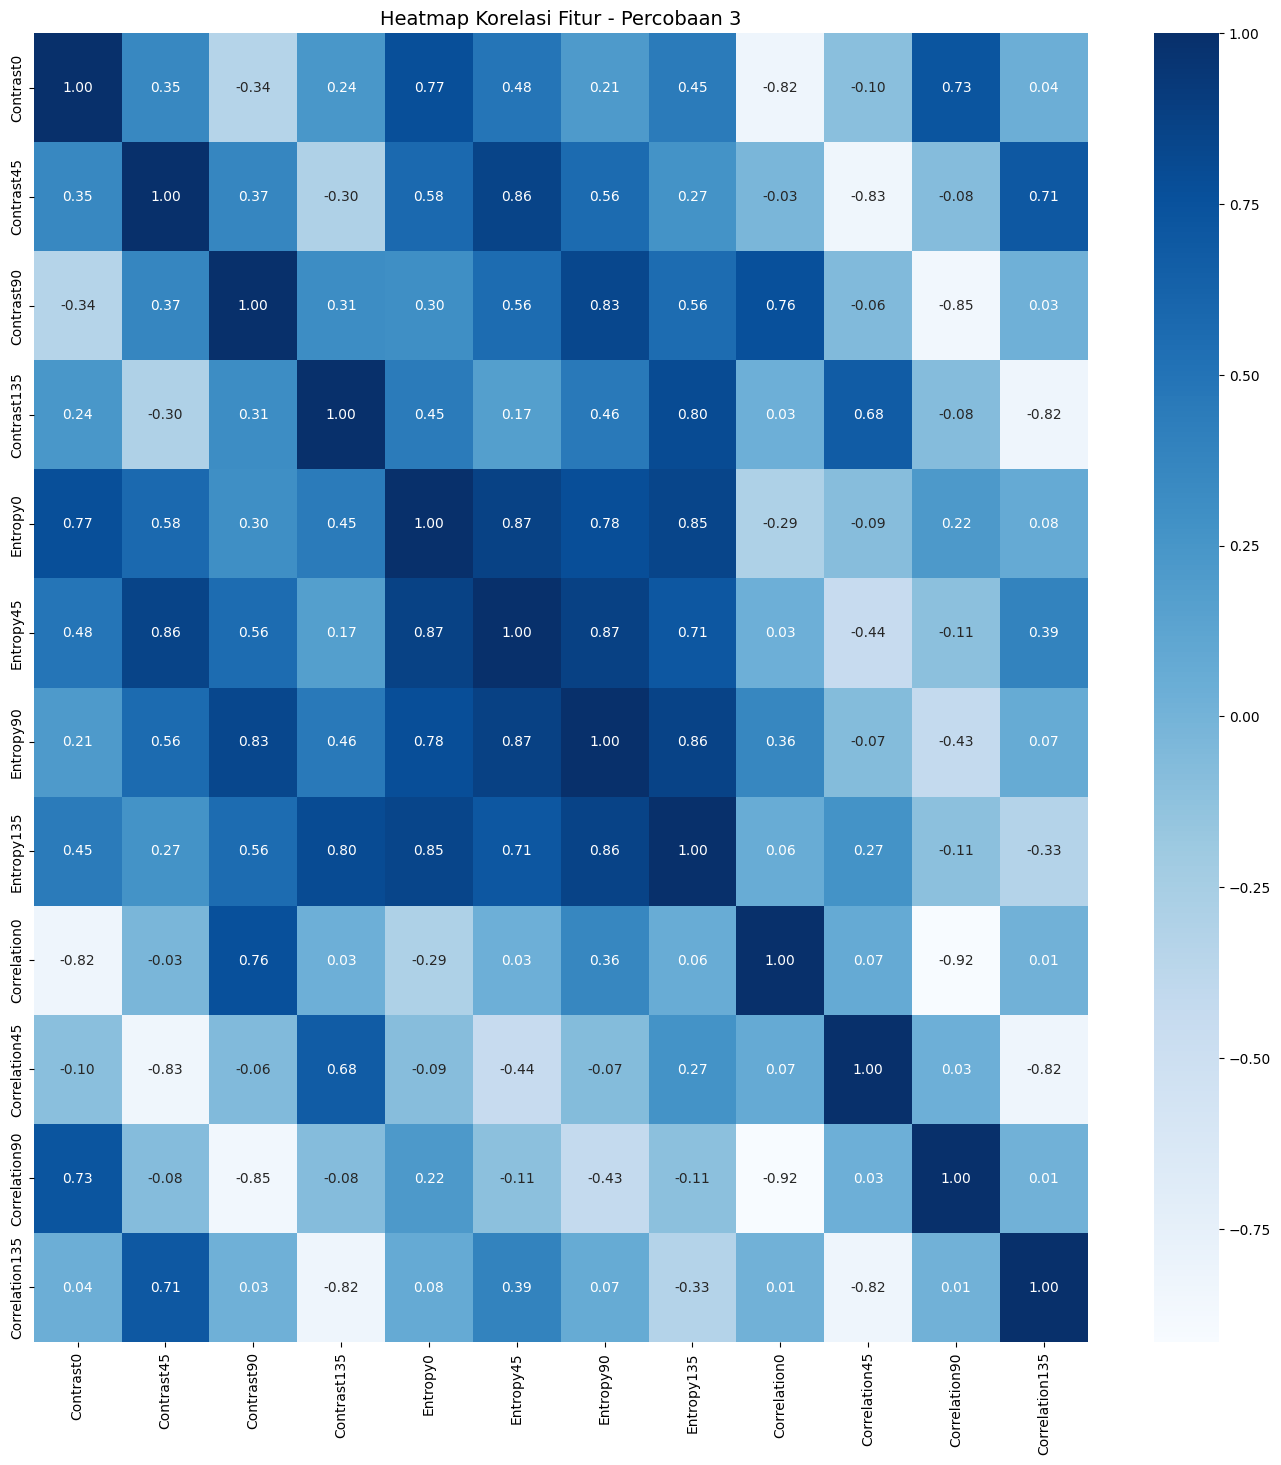

In [10]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

## Pemisahan Data Latih dan Data Uji
Blok kode ini berfungsi untuk membagi dataset fitur dan label menjadi dua bagian utama: data latih (*training set*) dan data uji (*testing set*). Menggunakan fungsi `train_test_split`, proporsi data diatur menjadi 80% untuk pelatihan dan 20% untuk pengujian melalui parameter `test_size=0.2`. Penggunaan parameter `random_state=42` memastikan bahwa proses pengacakan data tetap konsisten dan dapat direproduksi pada setiap pengeksekusian. Terakhir, program mencetak ukuran dimensi dari data latih dan uji untuk memverifikasi kebenaran proses pembagian tersebut.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(400, 12)
(100, 12)


## Standardisasi Data (Z-Score Normalization)
Blok kode ini melakukan standardisasi data agar rentang nilai pada setiap fitur menjadi seragam dan seimbang. Proses dimulai dengan menghitung nilai rata-rata (*mean*) dan simpangan baku (*standard deviation*) secara eksklusif hanya dari data latih. Kedua nilai statistik tersebut kemudian diaplikasikan menggunakan rumus *Z-score* untuk menskalakan ulang baik data latih maupun data uji. Penggunaan parameter dari data latih untuk menormalisasi data uji merupakan praktik penting guna mencegah terjadinya kebocoran informasi (*data leakage*), sehingga proses pengujian model tetap valid dan objektif.

In [12]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Evaluasi dan Inisialisasi Model
Blok kode ini mendefinisikan fungsi pembantu `generateClassificationReport` yang bertugas menampilkan ringkasan evaluasi model secara lengkap, meliputi laporan klasifikasi (presisi, *recall*, *F1-score*), matriks kebingungan (*confusion matrix*), dan skor akurasi keseluruhan. 

Selain fungsi evaluasi, program juga menginisialisasi tiga algoritma klasifikasi yang akan digunakan: *Random Forest* dengan pengaturan 5 pohon keputusan, *Support Vector Machine* (SVM) menggunakan *kernel Radial Basis Function* (RBF), serta *K-Nearest Neighbors* (KNN) yang menggunakan 5 tetangga terdekat. Parameter `random_state=42` diterapkan pada model Random Forest dan SVM untuk mengunci pengacakan internal, sehingga hasil pelatihan dan pengujian tetap konsisten setiap kali program dijalankan.

In [13]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Pelatihan dan Evaluasi Model Random Forest
Blok kode ini berfokus pada pelatihan model *Random Forest* menggunakan himpunan data latih melalui metode `fit`. Setelah proses pembelajaran selesai, model dievaluasi dalam dua tahapan terpisah. Tahap pertama melakukan prediksi terhadap data latih itu sendiri untuk meninjau seberapa baik model menghafal pola awal (berguna untuk melihat potensi *overfitting*). Selanjutnya, tahap kedua menguji model menggunakan data uji yang belum pernah dilihat sebelumnya untuk mengukur kemampuan generalisasi aslinya. Seluruh rekapitulasi metrik evaluasi dari kedua pengujian tersebut kemudian ditampilkan secara otomatis menggunakan fungsi `generateClassificationReport`.

In [14]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Arborio       0.95      0.99      0.97        72
     Basmati       0.99      0.99      0.99        86
      Ipsala       0.99      0.99      0.99        90
     Jasmine       0.97      0.96      0.97        76
   Karacadag       1.00      0.97      0.99        76

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

[[71  0  0  1  0]
 [ 0 85  1  0  0]
 [ 0  1 89  0  0]
 [ 3  0  0 73  0]
 [ 1  0  0  1 74]]
Accuracy: 0.98

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.61      0.71      0.66        28
     Basmati       0.79      0.79      0.79        14
      Ipsala       0.89      0.80      0.84        10
     Jasmine       0.73      0.67      0.70        24
   Karacadag       0.86      0.79      0.83        24

    accuracy                 

## Pelatihan dan Evaluasi Model SVM
Blok kode ini memiliki alur eksekusi yang identik dengan proses sebelumnya, namun kali ini diaplikasikan pada algoritma *Support Vector Machine* (SVM). Model SVM dilatih terlebih dahulu menggunakan himpunan data latih melalui metode `fit`. Setelah proses pembelajaran selesai, model dievaluasi dalam dua tahapan: pertama dengan memprediksi data latih untuk melihat seberapa baik model mengenali pola awal, lalu dilanjutkan dengan memprediksi data uji secara objektif untuk mengukur kemampuan generalisasinya terhadap data baru. Hasil rekapitulasi metrik evaluasi dari kedua tahap pengujian tersebut kemudian dicetak menggunakan fungsi `generateClassificationReport`.

In [15]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.92      0.79      0.85        72
     Basmati       0.99      0.97      0.98        86
      Ipsala       0.99      0.98      0.98        90
     Jasmine       0.89      0.97      0.93        76
   Karacadag       0.89      0.96      0.92        76

    accuracy                           0.94       400
   macro avg       0.94      0.93      0.93       400
weighted avg       0.94      0.94      0.94       400

[[57  0  1  5  9]
 [ 0 83  0  3  0]
 [ 1  1 88  0  0]
 [ 2  0  0 74  0]
 [ 2  0  0  1 73]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.86      0.89      0.88        28
     Basmati       0.93      0.93      0.93        14
      Ipsala       1.00      0.90      0.95        10
     Jasmine       0.92      0.96      0.94        24
   Karacadag       0.91      0.88      0.89        24

    accuracy              

## Pelatihan dan Evaluasi Model KNN
Blok kode ini menerapkan alur pelatihan dan pengujian yang serupa dengan model-model sebelumnya, namun kali ini difokuskan pada algoritma *K-Nearest Neighbors* (KNN). Proses diawali dengan melatih model menggunakan data latih melalui metode `fit`. Setelah itu, evaluasi dilakukan dalam dua tahapan: pertama dengan memprediksi data latih untuk meninjau kecocokan pola awal, lalu dilanjutkan dengan memprediksi data uji secara objektif untuk mengukur kemampuan adaptasi model terhadap data baru. Seluruh metrik evaluasi dari kedua tahap tersebut kemudian dirangkum dan dicetak menggunakan fungsi `generateClassificationReport`.

In [16]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.91      0.85      0.88        72
     Basmati       0.98      0.94      0.96        86
      Ipsala       0.98      0.97      0.97        90
     Jasmine       0.93      0.97      0.95        76
   Karacadag       0.89      0.95      0.92        76

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.94       400

[[61  0  0  2  9]
 [ 0 81  2  3  0]
 [ 1  2 87  0  0]
 [ 2  0  0 74  0]
 [ 3  0  0  1 72]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.88      0.82      0.85        28
     Basmati       0.92      0.86      0.89        14
      Ipsala       0.90      0.90      0.90        10
     Jasmine       0.85      0.92      0.88        24
   Karacadag       0.92      0.96      0.94        24

    accuracy              

## Visualisasi Matriks (Confusion Matrix)
Blok kode ini mendefinisikan fungsi pembantu `plot_confusion_matrix` untuk memvisualisasikan matriks kebingungan secara grafis. Fungsi ini bekerja dengan mengubah susunan matriks angka menjadi format antarmuka visual melalui `ConfusionMatrixDisplay` dan menerapkan skema warna gradasi biru (`cmap=plt.cm.Blues`) agar distribusi hasil prediksi lebih mudah dianalisis. 

Setelah fungsi pendukung dibuat, program memanggilnya sebanyak tiga kali berturut-turut untuk mencetak grafik evaluasi kinerja dari himpunan data uji pada masing-masing pengklasifikasi yang telah dilatih, yaitu Random Forest, SVM, dan KNN, lengkap dengan penyematan judul grafiknya.

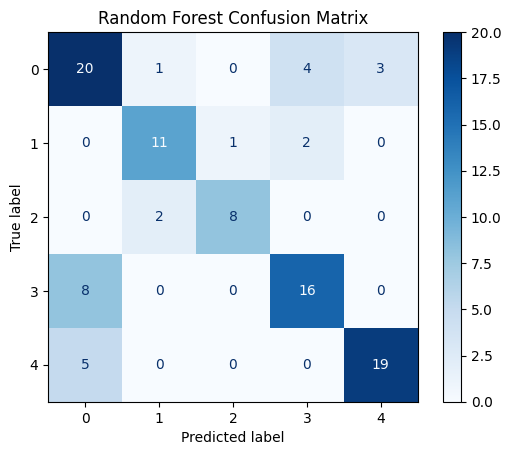

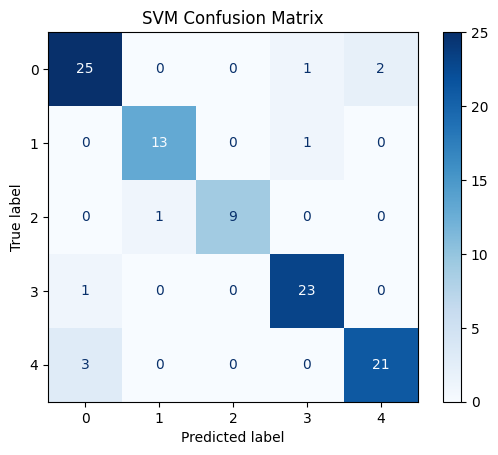

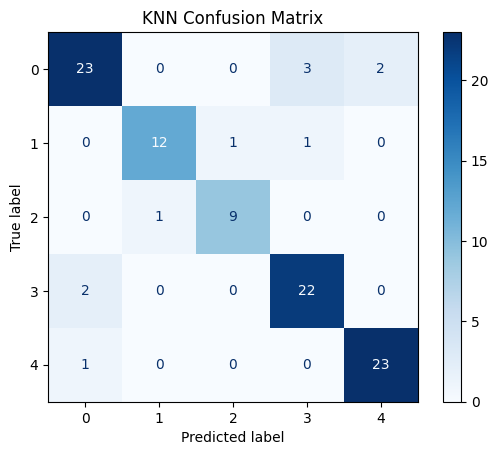

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Rekapitulasi dan Penyimpanan Hasil Evaluasi
Blok kode ini berfungsi untuk merekapitulasi dan membandingkan seluruh metrik kinerja dari ketiga model klasifikasi (Random Forest, SVM, dan KNN) ke dalam satu struktur data tabel yang rapi. Program secara otomatis mengekstrak skor akurasi (baik pada himpunan data latih maupun data uji), beserta metrik presisi, *recall*, dan *F1-score* yang dihitung secara berbobot (*weighted*) untuk masing-masing model. 

Seluruh data metrik evaluasi tersebut kemudian dikumpulkan ke dalam sebuah *dictionary* dan dikonversi menjadi objek *DataFrame* menggunakan pustaka Pandas agar mudah dianalisis. Sebagai langkah terakhir, tabel komparasi performa model ini diekspor dan disimpan secara permanen ke dalam *file* berekstensi CSV (`hasil_klasifikasi4.csv`) sebagai dokumentasi final dari percobaan keempat, ditutup dengan pencetakan pesan konfirmasi keberhasilan dan penampilan wujud tabel ringkasannya secara langsung.

In [18]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi4.csv', index=False)
print("✅ File hasil_klasifikasi4.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi4.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.9800,0.74,0.750404,0.74,0.743034
1,SVM,0.9375,0.91,0.911310,0.91,0.910125
2,KNN,0.9375,0.89,0.890800,0.89,0.889469
